In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [23]:
df = pd.read_excel('Concrete_Data.xls')

print('Shape:', df.shape)
df.head()

Shape: (1030, 9)


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [25]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [26]:
df.isnull().sum()

,0
Cement (component 1)(kg in a m^3 mixture),0
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0
Fly Ash (component 3)(kg in a m^3 mixture),0
Water (component 4)(kg in a m^3 mixture),0
Superplasticizer (component 5)(kg in a m^3 mixture),0
Coarse Aggregate (component 6)(kg in a m^3 mixture),0
Fine Aggregate (component 7)(kg in a m^3 mixture),0
Age (day),0
"Concrete compressive strength(MPa, megapascals)",0


In [27]:
print('Duplicates:', df.duplicated().sum())

Duplicates: 25


In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df.reset_index()
df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


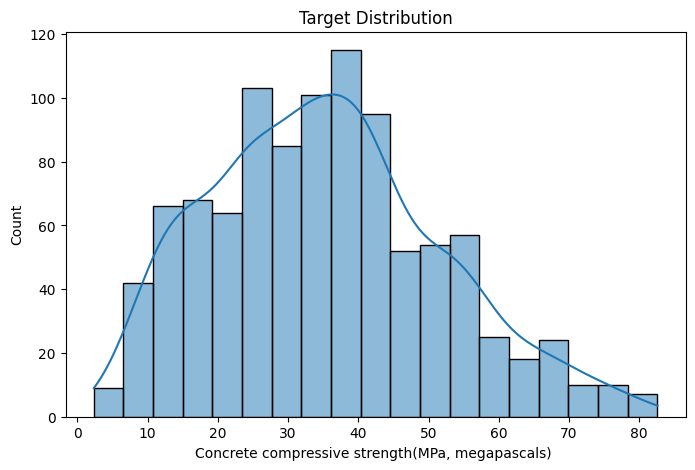

In [30]:
target = df.columns[-1]

plt.figure(figsize=(8,5))
sns.histplot(df[target], kde=True)
plt.title('Target Distribution')
plt.show()

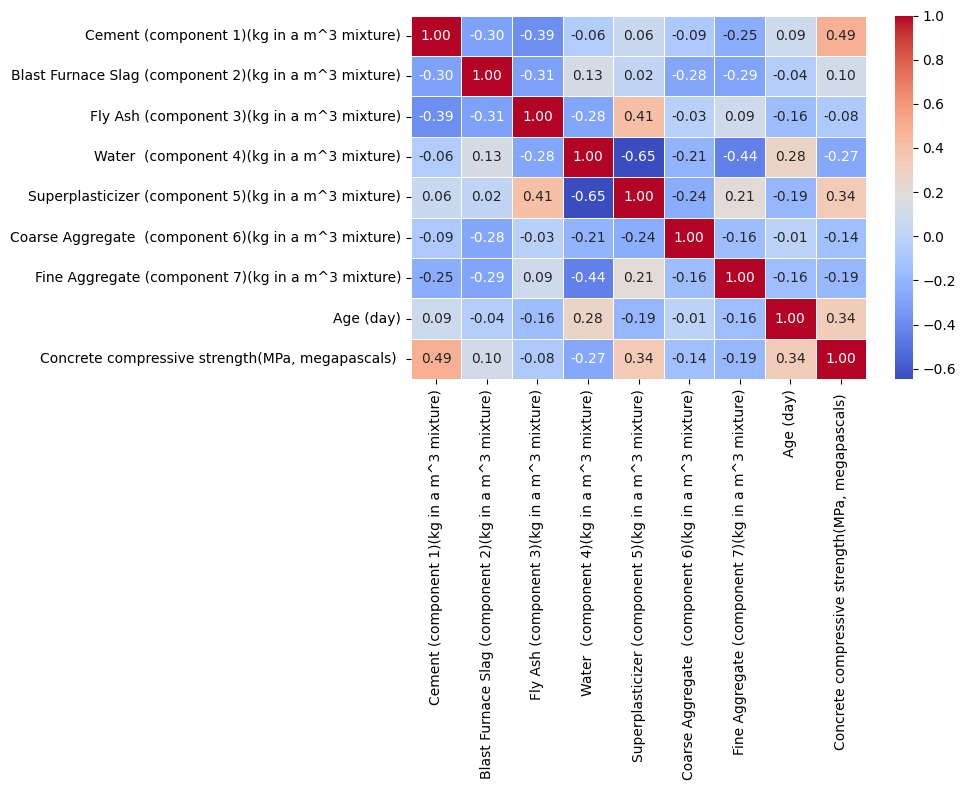

In [31]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.tight_layout()
plt.show()

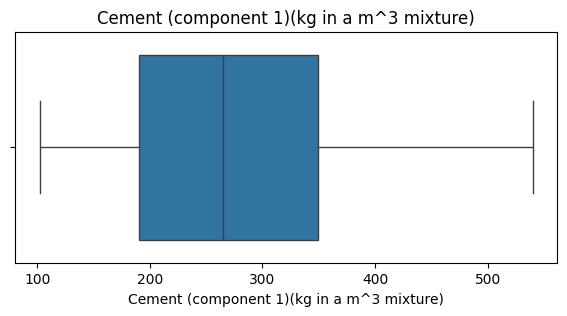

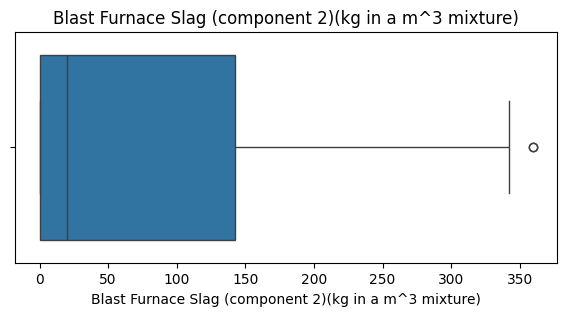

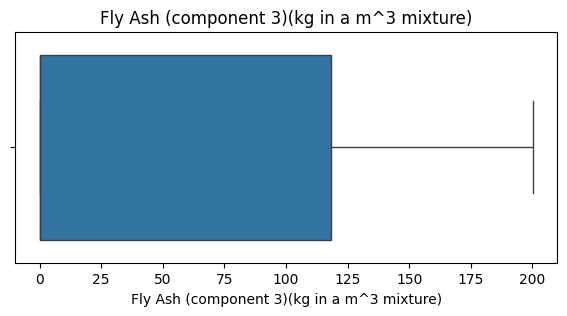

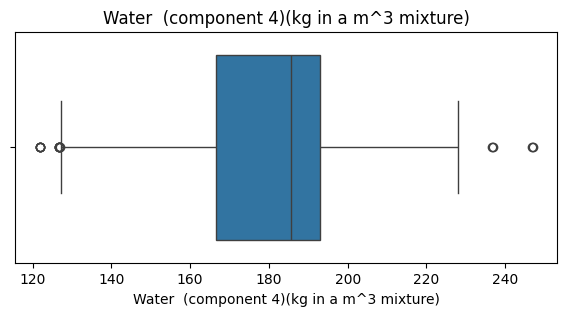

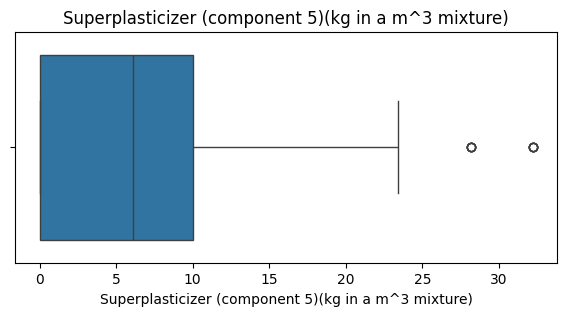

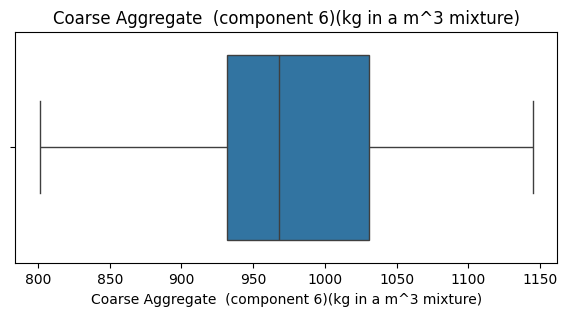

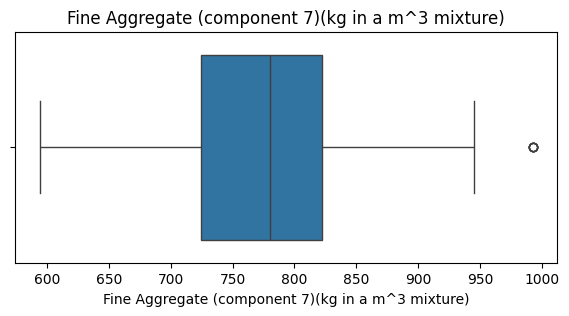

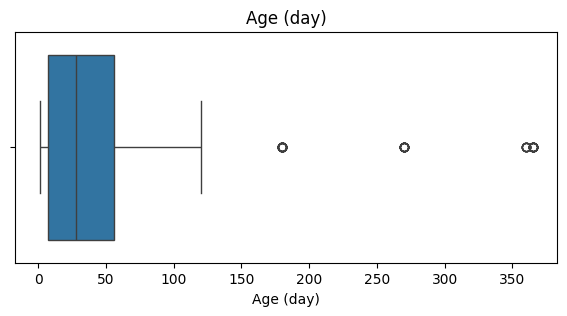

In [32]:
for col in df.columns[:-1]:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [33]:
# iqr method


In [34]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers and replace them with the median
for col in df.columns:
    median_val = df[col].median()
    df[col] = np.where(df[col] < lower_bound[col], median_val, df[col])
    df[col] = np.where(df[col] > upper_bound[col], median_val, df[col])

print("Outliers handled using IQR method. Replaced with median.")

Outliers handled using IQR method. Replaced with median.


After handling outliers, let's re-examine the descriptive statistics to see the impact.

In [35]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.629055,71.367711,55.535075,182.521294,5.791846,974.376468,771.628905,32.117413,34.883163
std,104.345003,85.239740,64.207448,20.114500,5.396851,77.579534,78.821267,27.665333,15.784825
min,102.000000,0.000000,0.000000,127.300000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,190.680000,0.000000,0.000000,168.000000,0.000000,932.000000,724.300000,7.000000,23.523542
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.798114
75%,349.000000,141.300000,118.270000,192.000000,9.900000,1031.000000,822.000000,28.000000,44.519465
max,540.000000,342.100000,200.100000,228.000000,23.400000,1145.000000,945.000000,120.000000,76.800732


In [36]:
target = df.columns[-1]

X = df.drop(target, axis=1)
y = df[target]

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
svr = SVR(kernel='rbf')

svr.fit(X_train, y_train)

pred = svr.predict(X_test)

print('MAE:', mean_absolute_error(y_test,pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test,pred)))
print('R2:', r2_score(y_test,pred))

MAE: 7.666346424678995
RMSE: 9.944957091304337
R2: 0.6168234334796705


### Improving Model Performance: More Extensive Hyperparameter Tuning

Based on the previous `GridSearchCV` results, the optimal parameters were `C=100`, `gamma='auto'`, and `kernel='rbf'`. To further improve the model, we will perform a more extensive search around these values. We'll refine the `param_grid` to explore a broader range for `C` and `gamma`.

In [40]:
print('Starting more extensive GridSearchCV for SVR...')

# Define an expanded parameter grid for a more thorough search
param_grid_improved = {
    'C': [50, 100, 200, 500, 1000],
    'gamma': ['scale', 'auto', 0.05, 0.1, 0.2, 0.001],
    'kernel': ['rbf'] # Focus on the best performing kernel identified
}

# Initialize GridSearchCV with the expanded parameter grid
grid_improved = GridSearchCV(
    SVR(),
    param_grid_improved,
    cv=5, # Using 5-fold cross-validation
    scoring='r2', # Optimize for R2 score
    n_jobs=-1, # Use all available CPU cores
    verbose=2 # Display progress messages
)

# Fit GridSearchCV to the training data
grid_improved.fit(X_train, y_train)

# Print the best parameters and corresponding best R2 score
print('\nImproved Best Parameters:', grid_improved.best_params_)
print('Improved Best Score:', grid_improved.best_score_)

Starting more extensive GridSearchCV for SVR...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Improved Best Parameters: {'C': 200, 'gamma': 'scale', 'kernel': 'rbf'}
Improved Best Score: 0.8523525581749244


### Retraining and Re-evaluating the Final Model with Improved Hyperparameters

Now, we'll use the best estimator found from the more extensive `GridSearchCV` to retrain our final model and evaluate its performance on the test set once again.

In [41]:
# Get the best model from the improved GridSearchCV
final_model_improved = grid_improved.best_estimator_

# Fit the final model to the training data
final_model_improved.fit(X_train, y_train)

# Make predictions on the test set
final_pred_improved = final_model_improved.predict(X_test)

# Calculate and print evaluation metrics for the improved model
print('Improved MAE:', mean_absolute_error(y_test, final_pred_improved))
print('Improved RMSE:', np.sqrt(mean_squared_error(y_test, final_pred_improved)))
print('Improved R2:', r2_score(y_test, final_pred_improved))

Improved MAE: 4.488419541410973
Improved RMSE: 7.8143210321235514
Improved R2: 0.7634213154629803


### Visualizing Actual vs. Predicted Values (Improved Model)

Let's visualize the actual versus predicted values for the improved model to see how well it fits the data.

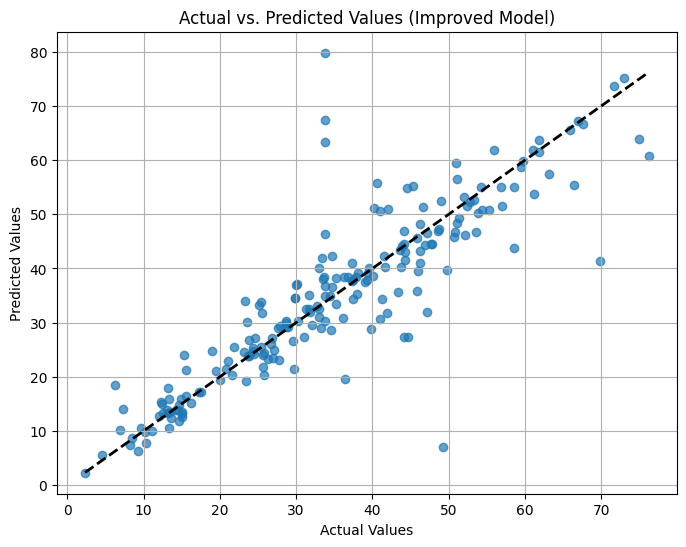

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, final_pred_improved, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values (Improved Model)')
plt.grid(True)
plt.show()

### Residual Plot (Improved Model)

A residual plot helps in understanding the errors of the model. Ideally, residuals should be randomly scattered around zero.

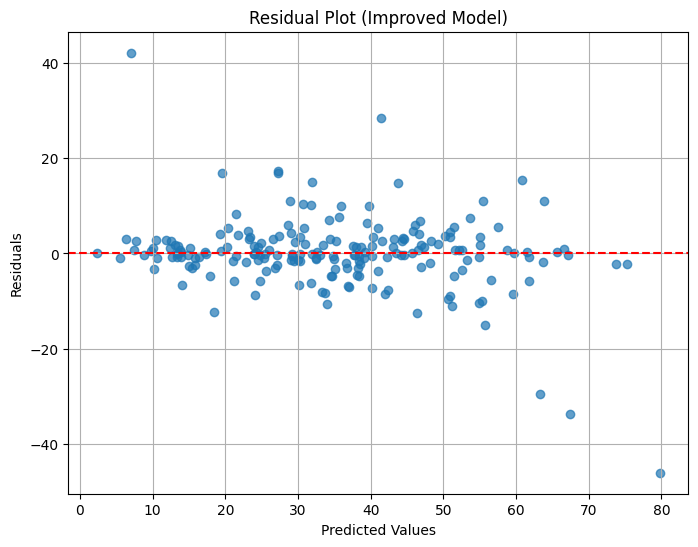

In [43]:
residuals_improved = y_test - final_pred_improved

plt.figure(figsize=(8,6))
plt.scatter(final_pred_improved, residuals_improved, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--') # Horizontal line at zero for reference
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Improved Model)')
plt.grid(True)
plt.show()

In [45]:
final_model = grid_improved.best_estimator_

final_model.fit(X_train,y_train)

final_pred = final_model.predict(X_test)

print('MAE:', mean_absolute_error(y_test,final_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test,final_pred)))
print('R2:', r2_score(y_test,final_pred))

MAE: 4.488419541410973
RMSE: 7.8143210321235514
R2: 0.7634213154629803


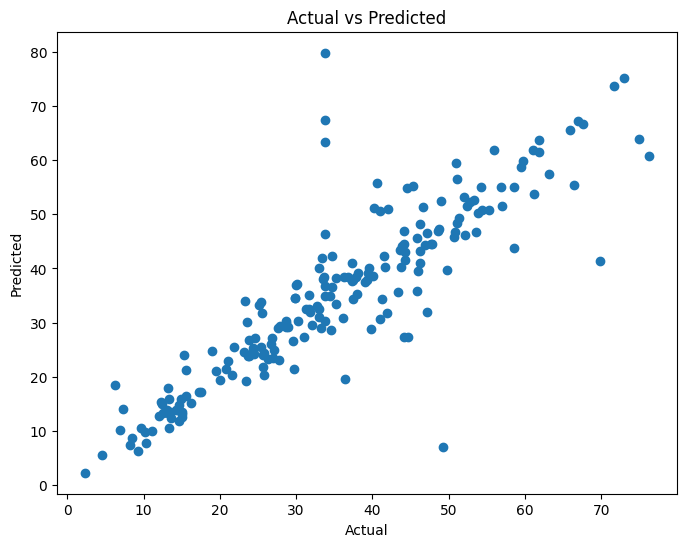

In [46]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, final_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

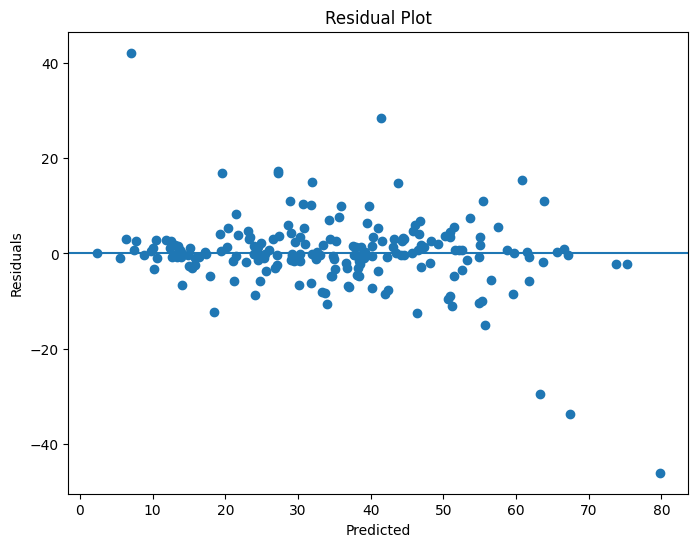

In [47]:
residuals = y_test - final_pred

plt.figure(figsize=(8,6))
plt.scatter(final_pred, residuals)
plt.axhline(y=0)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [48]:
joblib.dump(final_model,'concrete_svr_model.pkl')
print('Model Saved')

Model Saved
